<a href="https://colab.research.google.com/github/grumpyoldking/COMP3710/blob/main/COMP3710.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

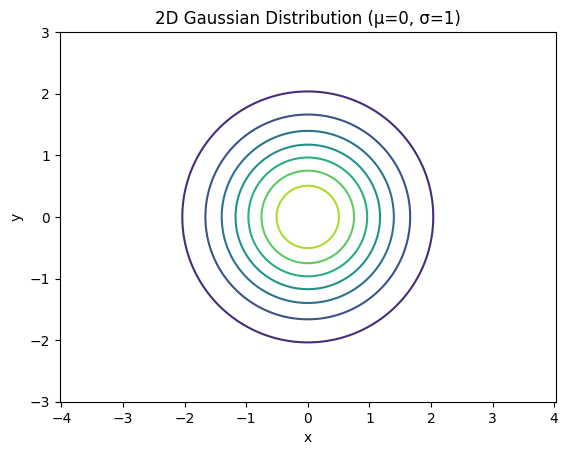

In [1]:
#!/usr/bin/env python3
"""
gaussian2d_plot.py

Generate and display a 2D Gaussian distribution using NumPy and Matplotlib.
"""

import numpy as np
import matplotlib.pyplot as plt

def gaussian_2d(x, y, mu=0.0, sigma=1.0):
    """
    Compute the value of a 2D Gaussian at points (x, y).

    f(x,y) = 1/(2πσ²) * exp( -((x-μ)² + (y-μ)²) / (2σ²) )
    """
    coeff = 1.0 / (2.0 * np.pi * sigma**2)
    exponent = -((x - mu)**2 + (y - mu)**2) / (2.0 * sigma**2)
    return coeff * np.exp(exponent)

def main():
    # Grid settings
    grid_size = 200       # number of points along each axis
    grid_limit = 3.0      # ± limit on both axes

    x = np.linspace(-grid_limit, grid_limit, grid_size)
    y = np.linspace(-grid_limit, grid_limit, grid_size)
    X, Y = np.meshgrid(x, y)

    # Compute Gaussian values on the grid
    Z = gaussian_2d(X, Y, mu=0.0, sigma=1.0)

    # Plot using a contour map
    plt.figure()
    plt.contour(X, Y, Z)
    plt.title("2D Gaussian Distribution (μ=0, σ=1)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")  # Ensure aspect ratio is equal
    plt.show()

if __name__ == "__main__":
    main()


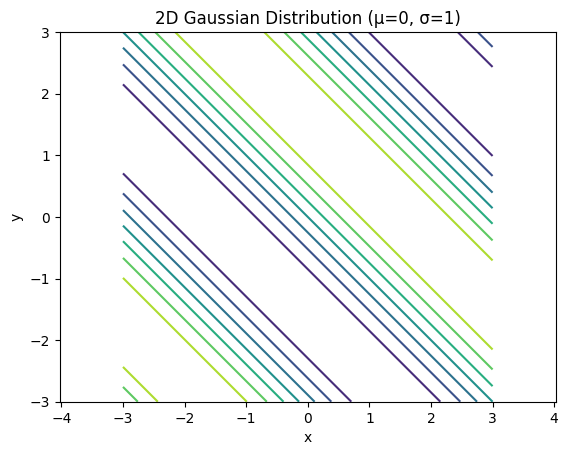

In [2]:
def sin_2d(x,y, mu = 0.0, sigma = 1.0):
  return np.sin(x+y)

def main():
    # Grid settings
    grid_size = 200       # number of points along each axis
    grid_limit = 3.0      # ± limit on both axes

    x = np.linspace(-grid_limit, grid_limit, grid_size)
    y = np.linspace(-grid_limit, grid_limit, grid_size)
    X, Y = np.meshgrid(x, y)

    # Compute Gaussian values on the grid
    Z = sin_2d(X, Y, mu = 0.0, sigma = 1.0)

    # Plot using a contour map
    plt.figure()
    plt.contour(X, Y, Z)
    plt.title("2D Gaussian Distribution (μ=0, σ=1)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")  # Ensure aspect ratio is equal
    plt.show()

if __name__ == "__main__":
    main()


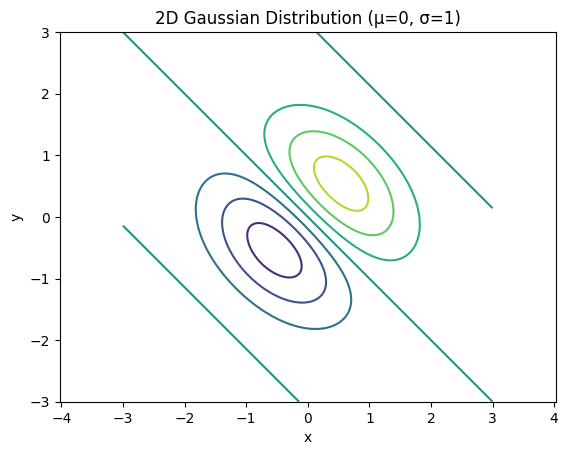

In [3]:
def main():
    # Grid settings
    grid_size = 200       # number of points along each axis
    grid_limit = 3.0      # ± limit on both axes

    x = np.linspace(-grid_limit, grid_limit, grid_size)
    y = np.linspace(-grid_limit, grid_limit, grid_size)
    X, Y = np.meshgrid(x, y)

    # Compute Gaussian values on the grid
    Z = sin_2d(X, Y, mu = 0.0, sigma = 1.0)
    f = gaussian_2d(X, Y, mu = 0.0, sigma = 1.0)
    g = f * Z

    # Plot using a contour map
    plt.figure()
    plt.contour(X, Y, g)
    plt.title("2D Gaussian Distribution (μ=0, σ=1)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")  # Ensure aspect ratio is equal
    plt.show()

if __name__ == "__main__":
    main()

Part 2

C:\Users\Ant0n\AppData\Local\Temp\ipykernel_29772\2219859827.py:40: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np.uint8(np.clip(a, 0, 255))


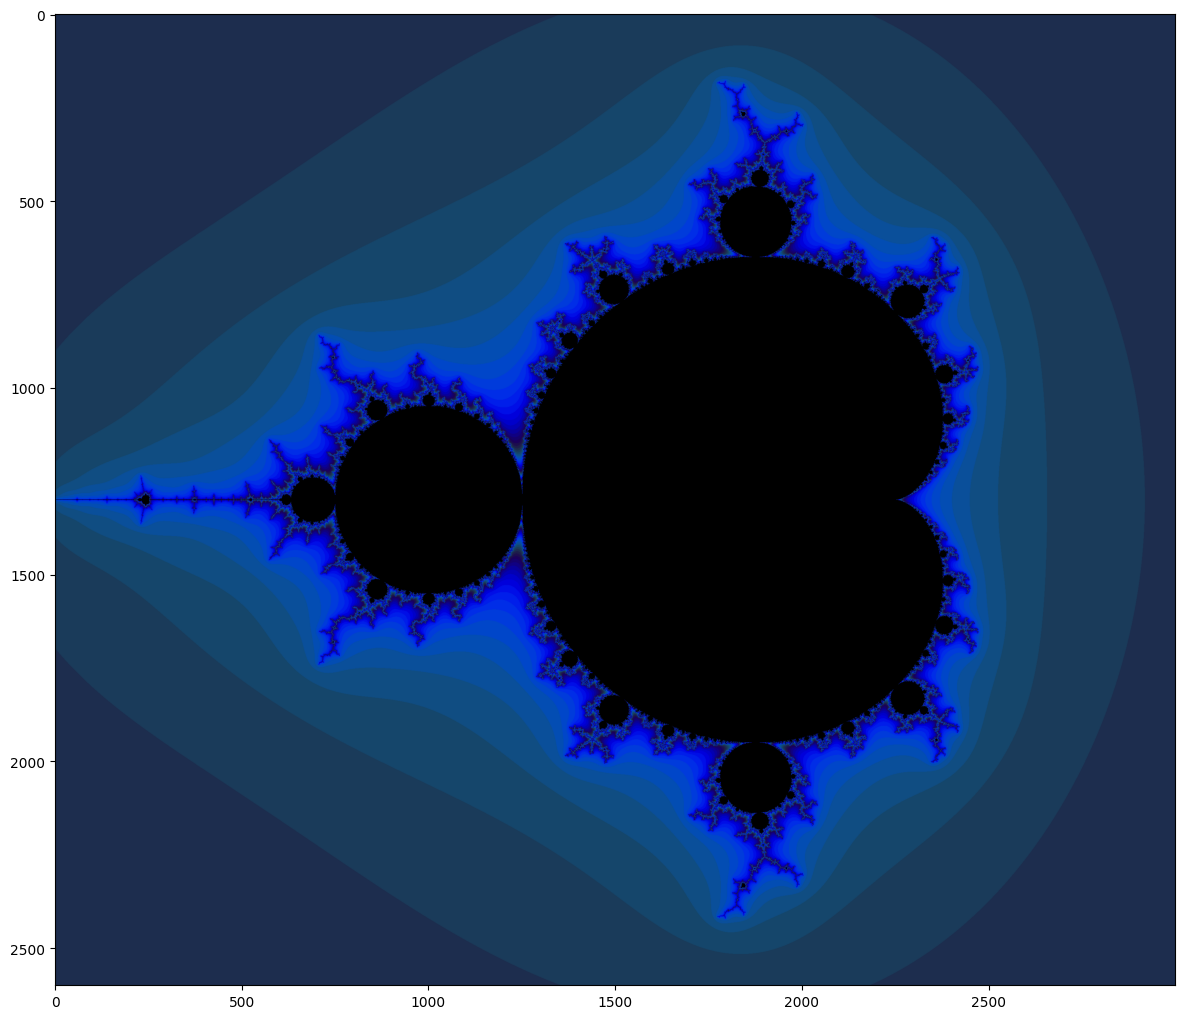

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
Y, X = np.mgrid[-1.3:1.3:0.001, -2:1:0.001]

x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y) #important!
zs = z.clone() #Updated!
ns = torch.zeros_like(z)

z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

#Mandelbrot Set
for i in range(200):
  #Compute the new values of z: z^2 + x
  zs_ = zs*zs + z
  #Have we diverged with this new value?
  not_diverged = torch.abs(zs_) < 4.0
  #Update variables to compute
  ns += not_diverged
  zs = zs_


fig = plt.figure(figsize = (16,10))

def processFractal(a):
  """Display an array of iteration counts as a
  colorful picture of a fractal."""
  a_cyclic = (6.28*a/20.0).reshape(list(a.shape)+[1])
  img = np.concatenate([10+20*np.cos(a_cyclic),
  30+50*np.sin(a_cyclic),
  155-80*np.cos(a_cyclic)], 2)
  img[a==a.max()] = 0
  a = img
  a = np.uint8(np.clip(a, 0, 255))
  return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

C:\Users\Ant0n\AppData\Local\Temp\ipykernel_29772\3745583945.py:43: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np.uint8(np.clip(a, 0, 255))


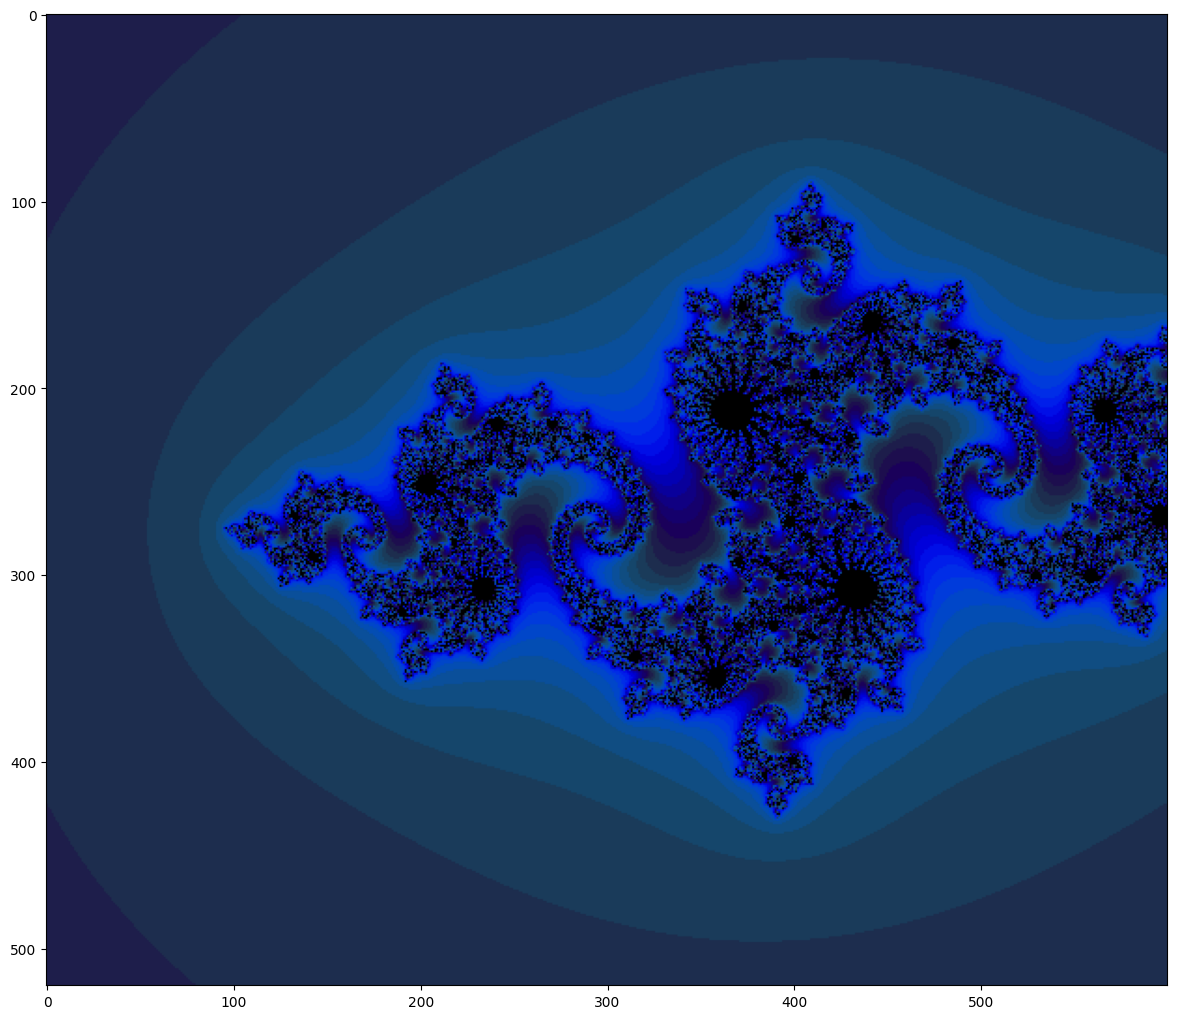

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
Y, X = np.mgrid[-1.3:1.3:0.005, -2:1:0.005]

x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y) #important!
zs = z.clone() #Updated!
ns = torch.zeros_like(z)
c = -0.8 + 0.156j
c_t = torch.tensor(c, dtype = torch.complex64)

Z0 = X + 1j * Y
z = z.to(device)
zs = torch.from_numpy(Z0).to(device)
ns = ns.to(device)

#Mandelbrot Set
for i in range(200):
  #Compute the new values of z: z^2 + x
  zs_ = zs*zs + c_t
  #Have we diverged with this new value?
  not_diverged = torch.abs(zs_) < 4.0
  #Update variables to compute
  ns += not_diverged
  zs = zs_


fig = plt.figure(figsize = (16,10))

def processFractal(a):
  """Display an array of iteration counts as a
  colorful picture of a fractal."""
  a_cyclic = (6.28*a/20.0).reshape(list(a.shape)+[1])
  img = np.concatenate([10+20*np.cos(a_cyclic),
  30+50*np.sin(a_cyclic),
  155-80*np.cos(a_cyclic)], 2)
  img[a==a.max()] = 0
  a = img
  a = np.uint8(np.clip(a, 0, 255))
  return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()